# Problem 4: Variational Autoencoder (VAE) for Emotion Space

## Learning a Continuous Emotion Latent Space (PyTorch)

---

## Problem Statement

**Goal**: Learn a **continuous latent representation** of emotions where:
- Similar emotions cluster together
- Can **interpolate** between emotions
- Data augmentation by sampling from latent space

### Why VAE over Regular Autoencoder?
- VAE learns a **probabilistic** latent space (Gaussian distribution)
- **Regularized** latent space prevents overfitting, encourages smoothness
- Can **generate** new samples by sampling from latent space

### Loss Function
```
VAE_Loss = Reconstruction_Loss (MSE) + beta * KL_Divergence
```

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import glob
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0+cu128
Device: cuda


## 2. Data Loading

In [2]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Data directory in Google Drive
DATA_DIR = Path("/content/drive/MyDrive/Speech-Emotion-Recognition-/data")

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_ravdess_filename(filepath):
    name = Path(filepath).stem
    parts = name.split("-")
    if len(parts) != 7:
        return None
    return {
        "file_path": filepath,
        "emotion_label": EMOTION_MAP.get(parts[2]),
    }

wav_paths = sorted(glob.glob(str(DATA_DIR / "Actor_*" / "*.wav")))
rows = [r for r in (parse_ravdess_filename(p) for p in wav_paths) if r]
df = pd.DataFrame(rows)

print(f"Found {len(df)} files")
print(df['emotion_label'].value_counts())

Mounted at /content/drive
Found 1440 files
emotion_label
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


## 3. Feature Extraction: Mel-Spectrograms

In [3]:
from multiprocessing import Pool, cpu_count
from tqdm.notebook import tqdm
import numpy as np

SAMPLE_RATE = 22050
N_MELS = 64
N_FFT = 2048
HOP_LENGTH = 512
MAX_TIME_FRAMES = 128

def extract_mel_spectrogram(file_path):
    try:
        y, _ = librosa.load(file_path, sr=SAMPLE_RATE)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=SAMPLE_RATE,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Pad or truncate
        if mel_db.shape[1] < MAX_TIME_FRAMES:
            mel_db = np.pad(
                mel_db,
                ((0, 0), (0, MAX_TIME_FRAMES - mel_db.shape[1])),
                mode='constant'
            )
        else:
            mel_db = mel_db[:, :MAX_TIME_FRAMES]

        return mel_db

    except Exception:
        return None


# Worker function
def process_row(row):
    features = extract_mel_spectrogram(row['file_path'])

    if features is not None:
        return features, row['emotion_label']

    return None


print("Extracting mel spectrograms in parallel...")

rows = df.to_dict('records')

with Pool(processes=cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(process_row, rows),
            total=len(rows)
        )
    )

# Remove failed rows
results = [r for r in results if r is not None]

# Build arrays
X = np.array([r[0] for r in results], dtype=np.float32)
y = np.array([r[1] for r in results])

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Optional: add channel dimension for CNNs
X = X[..., np.newaxis]

print(f"CNN input shape: {X.shape}")

Extracting mel spectrograms in parallel...


  0%|          | 0/1440 [00:00<?, ?it/s]


Features shape: (1440, 64, 128)
Labels shape: (1440,)
CNN input shape: (1440, 64, 128, 1)


In [4]:
print("Extracting mel-spectrograms...")

X, y = [], []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    mel = extract_mel_spectrogram(row['file_path'])
    if mel is not None:
        X.append(mel)
        y.append(row['emotion_label'])

X = np.array(X)[:, np.newaxis, :, :]  # Add channel dimension: (N, 1, H, W)
y = np.array(y)

# Normalize to [0, 1]
X_min, X_max = X.min(), X.max()
X_norm = (X - X_min) / (X_max - X_min)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

print(f"\nFeatures shape: {X.shape}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Extracting mel-spectrograms...


  0%|          | 0/1440 [00:00<?, ?it/s]


Features shape: (1440, 1, 64, 128)
Train: 1152, Test: 288


## 4. PyTorch Dataset

In [5]:
class MelSpectrogramDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

BATCH_SIZE = 32
train_dataset = MelSpectrogramDataset(X_train, y_train)
test_dataset = MelSpectrogramDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 5. VAE Model Architecture

In [6]:
LATENT_DIM = 32
BETA = 1.0

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten(),
        )

        # Calculate flattened size: (64/8) * (128/8) * 128 = 8 * 16 * 128 = 16384
        self.fc_mu = nn.Linear(8 * 16 * 128, latent_dim)
        self.fc_logvar = nn.Linear(8 * 16 * 128, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 8 * 16 * 128)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 8, 16)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss, recon_loss, kl_loss


model = VAE(latent_dim=LATENT_DIM).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=16384, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=16384, out_features=32, bias=True)
  (fc_decode): Linear(in_features=32, out_features=16384, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=

## 6. Training

In [7]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
NUM_EPOCHS = 100

history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}

print("Starting VAE training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(X_batch)
        loss, recon_loss, kl_loss = vae_loss(recon_batch, X_batch, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    history['total_loss'].append(avg_loss)
    history['recon_loss'].append(avg_recon)
    history['kl_loss'].append(avg_kl)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")

torch.save(model.state_dict(), 'vae_model.pt')
print("\nTraining complete!")

Starting VAE training...
Epoch 10/100 - Loss: 109.4479, Recon: 84.3810, KL: 25.0669
Epoch 20/100 - Loss: 96.3583, Recon: 71.3824, KL: 24.9758
Epoch 30/100 - Loss: 90.9010, Recon: 66.0620, KL: 24.8390
Epoch 40/100 - Loss: 86.0535, Recon: 61.3278, KL: 24.7258
Epoch 50/100 - Loss: 81.3207, Recon: 57.0207, KL: 24.3000
Epoch 60/100 - Loss: 78.7521, Recon: 54.3282, KL: 24.4239
Epoch 70/100 - Loss: 77.7497, Recon: 52.8526, KL: 24.8972
Epoch 80/100 - Loss: 75.1098, Recon: 50.0158, KL: 25.0940
Epoch 90/100 - Loss: 73.6337, Recon: 48.8988, KL: 24.7349
Epoch 100/100 - Loss: 71.9301, Recon: 46.9169, KL: 25.0132

Training complete!


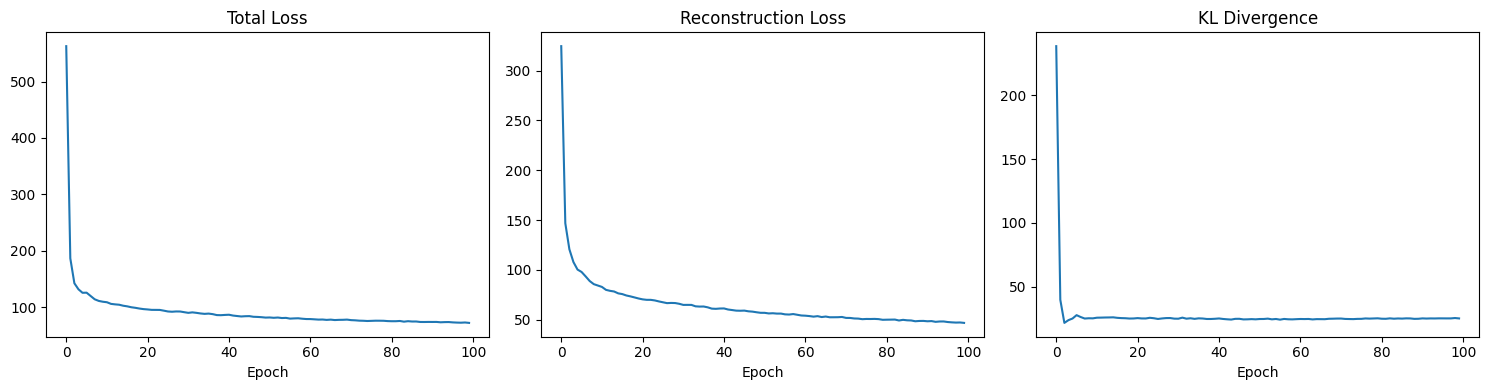

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['total_loss'])
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['recon_loss'])
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')

axes[2].plot(history['kl_loss'])
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('vae_training_curves.png', dpi=150)
plt.show()

## 7. Latent Space Visualization

In [9]:
# Get latent representations
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        mu, _ = model.encode(X_batch)
        all_mu.append(mu.cpu().numpy())
        all_labels.extend(y_batch.numpy())

z_mean = np.vstack(all_mu)
all_labels = np.array(all_labels)

print(f"Latent space shape: {z_mean.shape}")

Latent space shape: (288, 32)


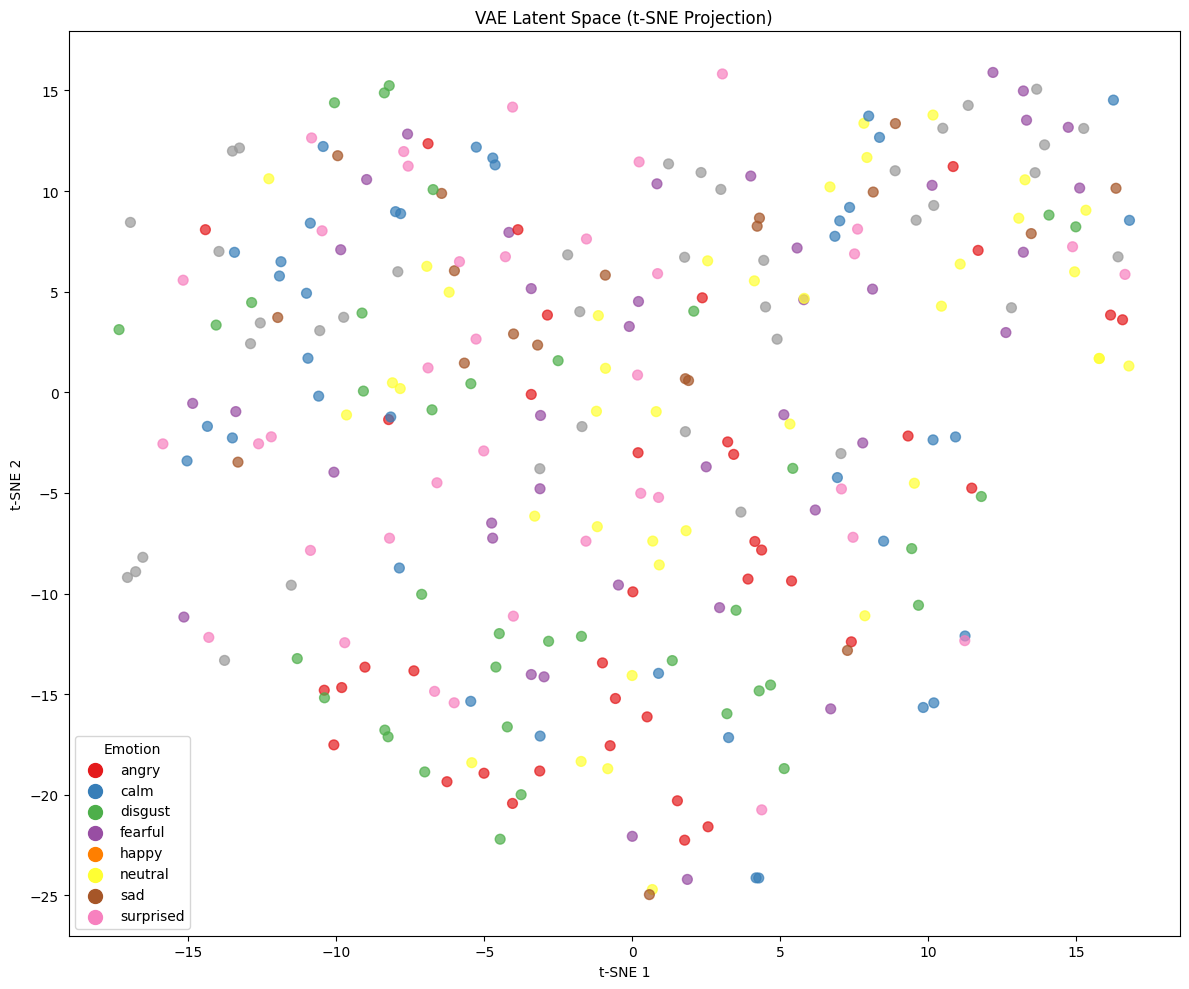

In [10]:
# t-SNE visualization
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_tsne = tsne.fit_transform(z_mean)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=all_labels, cmap='Set1', alpha=0.7, s=50)

handles = [plt.scatter([], [], c=plt.cm.Set1(i/8), s=100, label=label_encoder.classes_[i])
           for i in range(len(label_encoder.classes_))]
plt.legend(handles=handles, title='Emotion', loc='best')

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('VAE Latent Space (t-SNE Projection)')
plt.tight_layout()
plt.savefig('vae_latent_space_tsne.png', dpi=150)
plt.show()

## 8. Reconstruction Quality

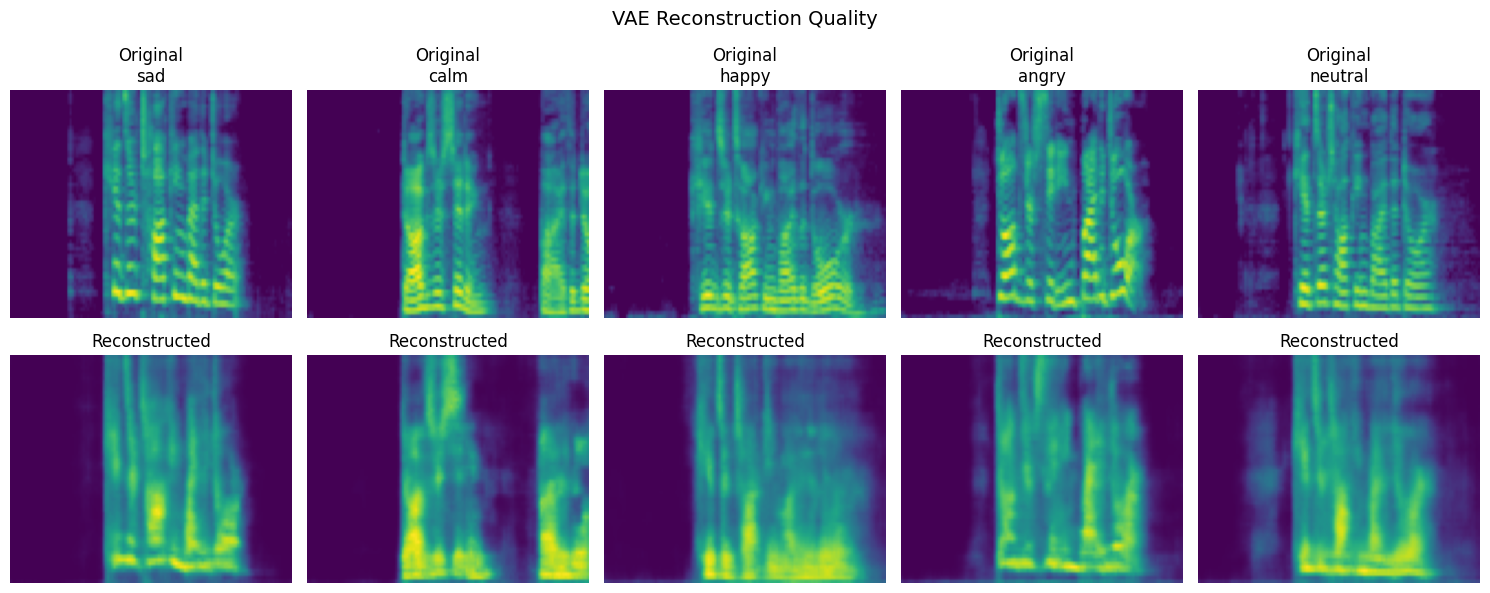

In [11]:
# Reconstruct test samples
model.eval()
X_test_tensor = torch.FloatTensor(X_test[:10]).to(device)

with torch.no_grad():
    reconstructions, _, _ = model(X_test_tensor)

reconstructions = reconstructions.cpu().numpy()

# Visualize
n_display = 5
fig, axes = plt.subplots(2, n_display, figsize=(15, 6))

for i in range(n_display):
    axes[0, i].imshow(X_test[i, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[0, i].set_title(f'Original\n{label_encoder.classes_[y_test[i]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(reconstructions[i, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.suptitle('VAE Reconstruction Quality', fontsize=14)
plt.tight_layout()
plt.savefig('vae_reconstruction_quality.png', dpi=150)
plt.show()

## 9. Emotion Interpolation

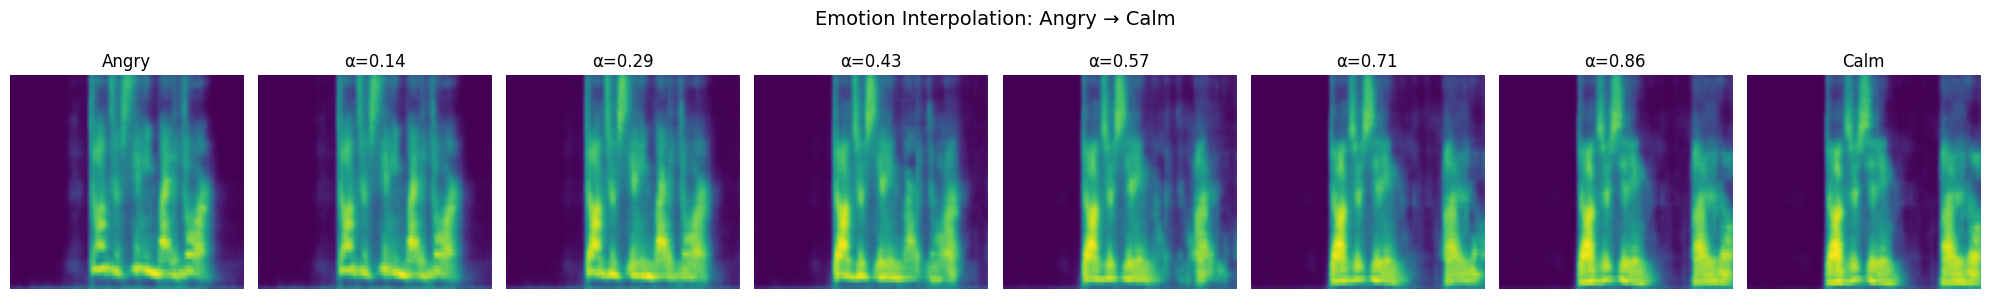

In [12]:
def interpolate_emotions(emotion1_idx, emotion2_idx, n_steps=8):
    idx1 = np.where(all_labels == emotion1_idx)[0][0]
    idx2 = np.where(all_labels == emotion2_idx)[0][0]

    z1 = z_mean[idx1]
    z2 = z_mean[idx2]

    alphas = np.linspace(0, 1, n_steps)
    z_interp = np.array([z1 * (1 - a) + z2 * a for a in alphas])

    with torch.no_grad():
        z_tensor = torch.FloatTensor(z_interp).to(device)
        decoded = model.decode(z_tensor).cpu().numpy()

    return decoded, alphas

# Interpolate angry -> calm
angry_idx = list(label_encoder.classes_).index('angry')
calm_idx = list(label_encoder.classes_).index('calm')

interpolated, alphas = interpolate_emotions(angry_idx, calm_idx)

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, (img, alpha) in enumerate(zip(interpolated, alphas)):
    axes[i].imshow(img[0], aspect='auto', origin='lower', cmap='viridis')
    if i == 0:
        axes[i].set_title('Angry')
    elif i == len(alphas) - 1:
        axes[i].set_title('Calm')
    else:
        axes[i].set_title(f'α={alpha:.2f}')
    axes[i].axis('off')

plt.suptitle('Emotion Interpolation: Angry → Calm', fontsize=14)
plt.tight_layout()
plt.savefig('vae_emotion_interpolation.png', dpi=150)
plt.show()

## 10. Classification from Latent Space

In [13]:
# Get train latent representations
model.eval()
train_mu = []

with torch.no_grad():
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        mu, _ = model.encode(X_batch)
        train_mu.append(mu.cpu().numpy())

z_train = np.vstack(train_mu)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf.fit(z_train, y_train)

# Evaluate
y_pred = clf.predict(z_mean)
print(f"Latent Space Classification Accuracy: {accuracy_score(all_labels, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, y_pred, target_names=label_encoder.classes_))

Latent Space Classification Accuracy: 0.1597

Classification Report:
              precision    recall  f1-score   support

       angry       0.21      0.21      0.21        38
        calm       0.11      0.13      0.12        38
     disgust       0.16      0.18      0.17        38
     fearful       0.15      0.18      0.16        39
       happy       0.20      0.21      0.20        39
     neutral       0.00      0.00      0.00        19
         sad       0.10      0.08      0.09        38
   surprised       0.20      0.21      0.20        39

    accuracy                           0.16       288
   macro avg       0.14      0.15      0.14       288
weighted avg       0.15      0.16      0.15       288



## 11. Key Takeaways

### Strengths of VAE for SER
- **Continuous latent space** allows emotion interpolation
- **Unsupervised learning** - can leverage unlabeled data
- **Data augmentation** by sampling from latent space

### Limitations
- Reconstruction quality may be blurry
- Classification accuracy usually lower than discriminative models
- KL weight (beta) requires tuning

### Practical Applications
1. **Pre-training**: Learn latent features, then fine-tune for classification
2. **Data augmentation**: Generate synthetic samples for minority classes
3. **Emotion transfer**: Modify emotional content while preserving speaker identity